#### 패션 MNIST
- 구두, 가방, 옷등의 이미지로 구성.
- 총 10개 class. (분류가 10개 => 10종류다)
- 28pixel * 28pixel = 784개의 Feature로 구성
- Sample수는 70000개 이다.


In [4]:
# !pip install tensorflow

In [5]:
# 데이터 불러오기

from tensorflow import keras

In [6]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
train_input

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [8]:
# Train Data의 외형
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [9]:
# Test Data의 외형
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


In [11]:
# train의 target data 파악
train_target[:9+1] # 10 개까지 출력 _0~9 까지의 숫자

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

- 0 : 티셔츠
- 1 : 바지
- 2 : 스웨터
- 3 : 드레스
- 4 : 코트
- 5 : 샌달
- 6 : 셔츠
- 7 : 스니커즈
- 8 : 가방
- 9 : 앵글 부츠

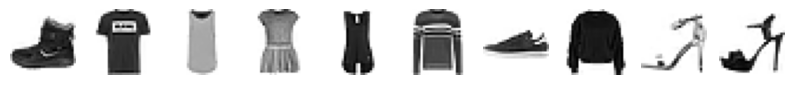

In [16]:
# train_input의 모양 10개만 출력
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize=(10, 10))
for i in range(9+1):
    axs[i].imshow(train_input[i], cmap='gray_r')  #imshow : 이미지 쇼우 , 이미지 보여주는 함수
    axs[i].axis('off') # 축 제거 _ x,y 축 제거 -> axis('off')

plt.show()

In [18]:
# train_target의 종류 및 갯수 파악
import numpy as np

print(np.unique(train_target, return_counts=True)) # 데이터 많을때는 넘파이 써야 함,return_counts=True : 데이터의 종류와 갯수 같이 출력

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


----
#### 로지스틱 회귀로 패션 아이템 분류하기

In [22]:
# 데이터 정규화 및 2차행렬로 만들기
train_scaled =train_input /255.0
train_scaled = train_scaled.reshape(-1,28*28)

In [23]:
# Dismension 확인
train_scaled.shape

(60000, 784)

In [28]:
# 로지스틱 회귀 모델
from  sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss',max_iter=5,random_state=42)


scores = cross_validate(
        sc,
        train_scaled,
        train_target,
        n_jobs=-1
)

print('평균:',np.mean(scores['test_score']))

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn

평균: 0.8191833333333334


---
### 인공신경망
#### Keras Model 만들기

In [29]:
# Train data를 훈련과 검증 데이터로 나누기

from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
                                                        train_scaled,
                                                        train_target,
                                                        test_size=0.2,
                                                        random_state=42
)

In [30]:
# Dimension 
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


#### Keras로 층 만들기

In [31]:
from tensorflow.keras.layers import Input

model = keras.Sequential()
model.add(Input(shape=(28*28,)))
model.add(keras.layers.Dense(10, activation='softmax')) # activation : 활성화 함수 , softmax : 확률로 바꿔주는 함수( sigmoid는 0~1 사이의 확률로 바꿔주는 함수, softmax는 여러개일 때 확률로 바꿔주는 함수)

In [32]:
# 손실함수
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy']) # sparse_categorical_crossentropy : 다중 분류 문제에서 사용되는 손실 함수, metrics : 평가 지표
# accuracy : 정확도,/ 손실함수를 뭐로 나눌껀지 적어주는 거 


In [ ]:
# 모델 훈련
model.fit(
    train_scaled, 
    train_target, 
    epochs=5
)
# 지금 한거 : 모델 훈련, epochs : 몇 번 반복할껀지 적어주는 거, 5번 반복하겠다.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 391us/step - accuracy: 0.7946 - loss: 0.6070
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 435us/step - accuracy: 0.8394 - loss: 0.4748
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 500us/step - accuracy: 0.8481 - loss: 0.4499
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 397us/step - accuracy: 0.8514 - loss: 0.4381
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 439us/step - accuracy: 0.8551 - loss: 0.4294


In [34]:
# 검증 데이터 확인 
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - accuracy: 0.8461 - loss: 0.4419


[0.4419281482696533, 0.8460833430290222]